# Intertidal Substrate Classification — Viana do Castelo, NW Portugal

Random-Forest classification of a Sentinel-2 low-tide composite into **Rock** and
**Seaweed**, with per-class probability, classification confidence, and georeferenced
map products.

**Pipeline:** training data → Random Forest (with accuracy / kappa / feature importance)
→ pixel-wise classification of the 13-band raster → publication figures + GeoTIFFs.

All inputs are in `data_used/`; all outputs are written to `figures/`.
Edit `BASE_DIR` below if you move the project.

In [1]:
# =============================================================================
# 0 · Imports & configuration  (single source of truth for paths, classes, style)
# =============================================================================
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, cohen_kappa_score)

try:
    import geopandas as gpd
    HAS_GPD = True
except Exception:
    HAS_GPD = False

# ---- Paths (relative: run this notebook from the project folder) -------------
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data_used')
FIG_DIR  = os.path.join(BASE_DIR, 'figures')
GEO_DIR  = os.path.join(FIG_DIR, 'georeferenced_maps')
os.makedirs(GEO_DIR, exist_ok=True)

RASTER_PATH = os.path.join(DATA_DIR, 'Lowtide_re.tif')
TRAIN_CSV   = os.path.join(DATA_DIR, 'training_points_scaled_with_coords1.csv')
SHAPEFILE   = os.path.join(DATA_DIR, 'pol_carreco_viana_2017.shp')

# ---- Semantics ---------------------------------------------------------------
FEATURES     = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','NDVI','NDWI','NDMI']
CLASS_NAMES  = {0: 'Rock', 1: 'Seaweed'}
CLASS_COLORS = {0: '#b58a4c', 1: '#2e7d32'}     # rock = tan, seaweed = green
RANDOM_STATE = 42
NODATA       = -9999

# ---- Publication-quality matplotlib defaults ---------------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Cambria', 'DejaVu Serif'],
    'axes.titlesize': 15, 'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 11,
    'figure.dpi': 110, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'savefig.facecolor': 'white', 'axes.linewidth': 0.8,
})
print('Configuration loaded. Figures ->', FIG_DIR)

Configuration loaded. Figures -> /Users/priyankashukla/Documents/repos/BioEcoOcean/viana_de_castelo_seaweed_classification/figures


## 1 · Training data

In [2]:
# =============================================================================
# 1 · Load training samples
# =============================================================================
df = pd.read_csv(TRAIN_CSV).dropna(subset=FEATURES + ['class'])
X = df[FEATURES].values
y = df['class'].astype(int).values

print(f'Training samples : {len(y)}')
print(f'Features         : {len(FEATURES)}')
for c, n in zip(*np.unique(y, return_counts=True)):
    print(f'  class {c} ({CLASS_NAMES.get(c, c)}): {n}')

Training samples : 847
Features         : 13
  class 0 (Rock): 540
  class 1 (Seaweed): 307


## 2 · Train & evaluate the Random Forest

In [3]:
# =============================================================================
# 2 · Train / test split, scaling, Random Forest, accuracy assessment
# =============================================================================
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

rf = RandomForestClassifier(
    n_estimators=100, max_depth=15, min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', random_state=RANDOM_STATE)
rf.fit(X_tr_s, y_tr)

y_hat = rf.predict(X_te_s)
oa    = accuracy_score(y_te, y_hat)
kappa = cohen_kappa_score(y_te, y_hat)
cm    = confusion_matrix(y_te, y_hat, labels=sorted(CLASS_NAMES))
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

print(f'Overall accuracy : {oa:.3f}')
print(f'Cohen kappa      : {kappa:.3f}\n')
print(classification_report(y_te, y_hat,
      target_names=[CLASS_NAMES[c] for c in sorted(CLASS_NAMES)]))

Overall accuracy : 0.948
Cohen kappa      : 0.889

              precision    recall  f1-score   support

        Rock       0.97      0.95      0.96       135
     Seaweed       0.91      0.95      0.93        77

    accuracy                           0.95       212
   macro avg       0.94      0.95      0.94       212
weighted avg       0.95      0.95      0.95       212



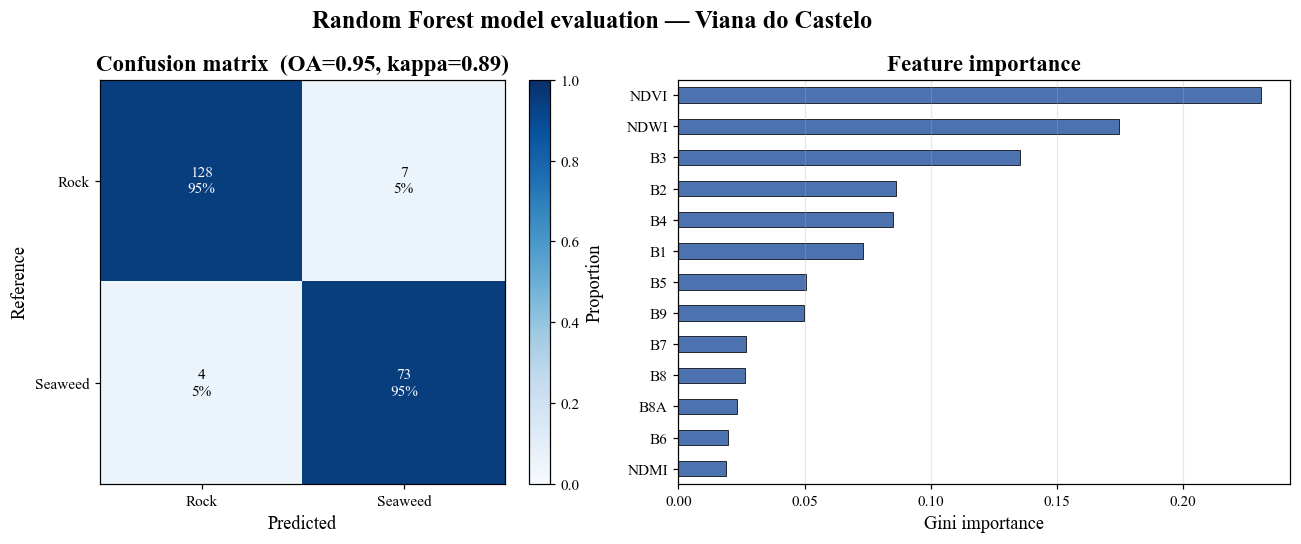

In [4]:
# ---- Figure: model evaluation (confusion matrix + feature importance) --------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
labels = [CLASS_NAMES[c] for c in sorted(CLASS_NAMES)]

cmn = cm / cm.sum(axis=1, keepdims=True)
im = ax1.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
ax1.set_xticks(range(len(labels))); ax1.set_yticks(range(len(labels)))
ax1.set_xticklabels(labels); ax1.set_yticklabels(labels)
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Reference')
ax1.set_title(f'Confusion matrix  (OA={oa:.2f}, kappa={kappa:.2f})', fontweight='bold')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax1.text(j, i, f'{cm[i, j]}\n{cmn[i, j]*100:.0f}%', ha='center', va='center',
                 color='white' if cmn[i, j] > 0.5 else 'black')
fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label='Proportion')

importances.plot.barh(ax=ax2, color='#4c72b0', edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Gini importance'); ax2.set_title('Feature importance', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

fig.suptitle('Random Forest model evaluation — Viana do Castelo',
             fontsize=16, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'Model_Evaluation.png'))
plt.show()

## 3 · Classify the raster

In [5]:
# =============================================================================
# 3 · Load the 13-band raster and classify every valid pixel
# =============================================================================
with rasterio.open(RASTER_PATH) as src:
    cube      = src.read().astype('float32')        # (bands, H, W)
    transform = src.transform
    crs       = src.crs
    bounds    = src.bounds
bands, H, W = cube.shape

flat  = np.transpose(cube, (1, 2, 0)).reshape(-1, bands)   # (H*W, bands)
valid = ~np.isnan(flat).any(axis=1)

proba = rf.predict_proba(scaler.transform(flat[valid]))
pred  = rf.classes_[proba.argmax(axis=1)]

def rebuild(values, fill=NODATA):
    out = np.full(flat.shape[0], fill, dtype='float32')
    out[valid] = values
    return out.reshape(H, W)

class_map = rebuild(pred)
prob_maps = {c: rebuild(proba[:, i]) for i, c in enumerate(rf.classes_)}
conf_map  = rebuild(proba.max(axis=1))
extent    = [bounds.left, bounds.right, bounds.bottom, bounds.top]

print(f'Raster      : {W} x {H} px, {bands} bands, CRS {crs}')
print(f'Valid pixels: {valid.sum():,} / {valid.size:,} '
      f'({100*valid.sum()/valid.size:.1f}%)')
for c in sorted(CLASS_NAMES):
    n = int((pred == c).sum())
    print(f'  {CLASS_NAMES[c]:8s}: {n:,} px ({100*n/valid.sum():.1f}%)')

Raster      : 406 x 841 px, 13 bands, CRS EPSG:4326
Valid pixels: 24,136 / 341,446 (7.1%)
  Rock    : 23,496 px (97.3%)
  Seaweed : 640 px (2.7%)


## 4 · Publication maps & GeoTIFF products

In [6]:
# =============================================================================
# 4a · Cartographic helpers  (colormaps, decorations, plotting, GeoTIFF export)
# =============================================================================
# Geographic aspect for plate-carree (EPSG:4326) so shapes are not distorted
MEAN_LAT = (bounds.bottom + bounds.top) / 2
ASPECT   = 1.0 / np.cos(np.radians(MEAN_LAT))
M_PER_DEG_LON = 111_320 * np.cos(np.radians(MEAN_LAT))

lon_range = bounds.right - bounds.left
lat_range = bounds.top - bounds.bottom
MAP_W = 5.0
MAP_H = MAP_W * (lat_range * ASPECT) / lon_range   # true geographic proportions

# Sequential ramps keyed to the class colours; confidence uses viridis (colour-blind safe)
cmap_rock    = LinearSegmentedColormap.from_list('rock',    ['white', CLASS_COLORS[0]])
cmap_seaweed = LinearSegmentedColormap.from_list('seaweed', ['white', CLASS_COLORS[1]])
cmap_class   = ListedColormap([CLASS_COLORS[0], CLASS_COLORS[1]])

# Optional study-area polygon overlay
overlay = None
if HAS_GPD and os.path.exists(SHAPEFILE):
    try:
        overlay = gpd.read_file(SHAPEFILE).to_crs(4326)
        print('Study-area polygon loaded for overlay.')
    except Exception as e:
        print('Shapefile overlay unavailable:', e)

def fmt_axes(ax, title):
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('Longitude (deg E)'); ax.set_ylabel('Latitude (deg N)')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))
    ax.set_aspect(ASPECT)

def add_decorations(ax, scale_km=1.0):
    lon0, lon1 = bounds.left, bounds.right
    lat0, lat1 = bounds.bottom, bounds.top
    # scale bar (bottom-left)
    bar = scale_km * 1000 / M_PER_DEG_LON
    x0 = lon0 + 0.08 * lon_range; y0 = lat0 + 0.04 * lat_range
    ax.plot([x0, x0 + bar], [y0, y0], color='black', lw=3, solid_capstyle='butt')
    ax.text(x0 + bar / 2, y0 + 0.012 * lat_range, f'{scale_km:g} km',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    # north arrow (top-left), 'N' above the arrowhead
    xa = lon0 + 0.09 * lon_range
    y_base = lat1 - 0.15 * lat_range
    y_tip  = lat1 - 0.07 * lat_range
    ax.annotate('', xy=(xa, y_tip), xytext=(xa, y_base),
                arrowprops=dict(arrowstyle='-|>', color='black', lw=1.8))
    ax.text(xa, y_tip + 0.012 * lat_range, 'N', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

def overlay_polygon(ax):
    if overlay is not None:
        overlay.boundary.plot(ax=ax, edgecolor='black', linewidth=1.1, linestyle='--')

def map_single(data, cmap, vmin, vmax, cbar_label, title, fname, overlay_poly=False):
    disp = np.where(data == NODATA, np.nan, data)
    fig, ax = plt.subplots(figsize=(MAP_W, MAP_H))
    im = ax.imshow(disp, cmap=cmap, vmin=vmin, vmax=vmax, extent=extent, origin='upper')
    fmt_axes(ax, title)
    if overlay_poly:
        overlay_polygon(ax)
    add_decorations(ax)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label, fontweight='bold')
    fig.tight_layout()
    fig.savefig(os.path.join(GEO_DIR, fname))
    plt.show(); plt.close(fig)
    print('saved', fname)

def map_classification(fname):
    disp = np.where(class_map == NODATA, np.nan, class_map)
    fig, ax = plt.subplots(figsize=(MAP_W, MAP_H))
    ax.imshow(disp, cmap=cmap_class, vmin=0, vmax=1, extent=extent, origin='upper')
    fmt_axes(ax, 'Final classification: Rock vs Seaweed\nViana do Castelo, NW Portugal')
    overlay_polygon(ax); add_decorations(ax)
    handles = [Patch(facecolor=CLASS_COLORS[c], edgecolor='black', label=CLASS_NAMES[c])
               for c in sorted(CLASS_NAMES)]
    if overlay is not None:
        handles.append(Line2D([0], [0], color='black', ls='--', label='Study area (2017)'))
    ax.legend(handles=handles, loc='upper right', framealpha=0.95, edgecolor='black')
    fig.tight_layout()
    fig.savefig(os.path.join(GEO_DIR, fname))
    plt.show(); plt.close(fig)
    print('saved', fname)

def save_geotiff(data, path, dtype='float32'):
    with rasterio.open(path, 'w', driver='GTiff', height=H, width=W, count=1,
                       dtype=dtype, crs=crs, transform=transform,
                       nodata=NODATA, compress='LZW') as dst:
        dst.write(data.astype(dtype), 1)

Study-area polygon loaded for overlay.


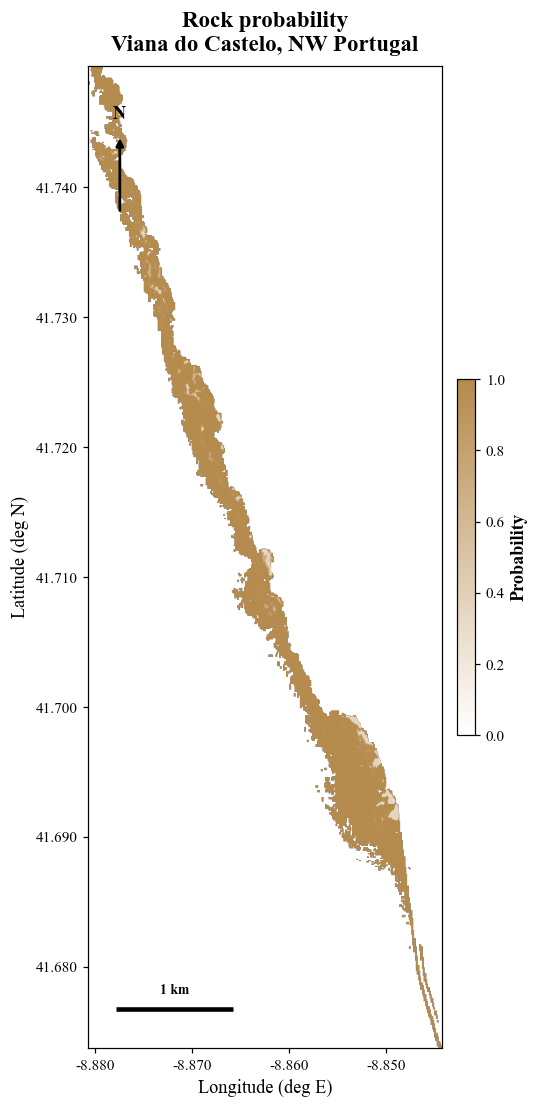

saved Class_0_Probability.png


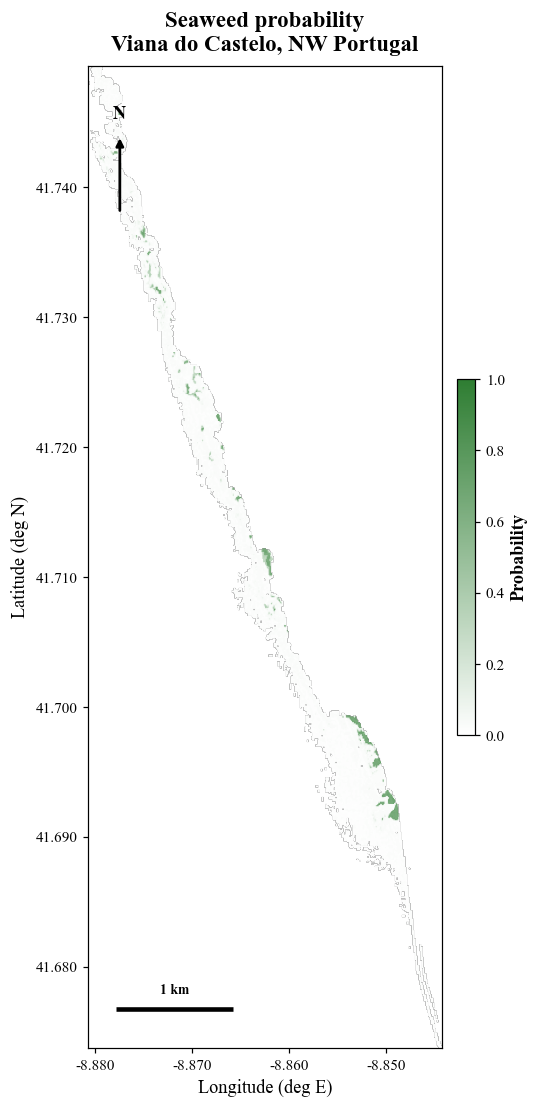

saved Class_1_Probability.png


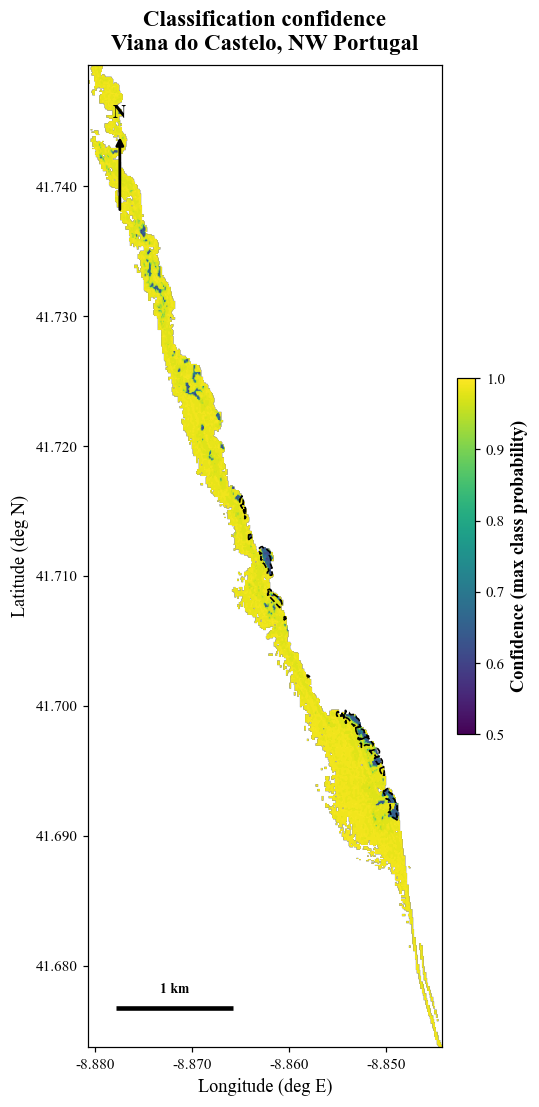

saved Classification_Confidence.png


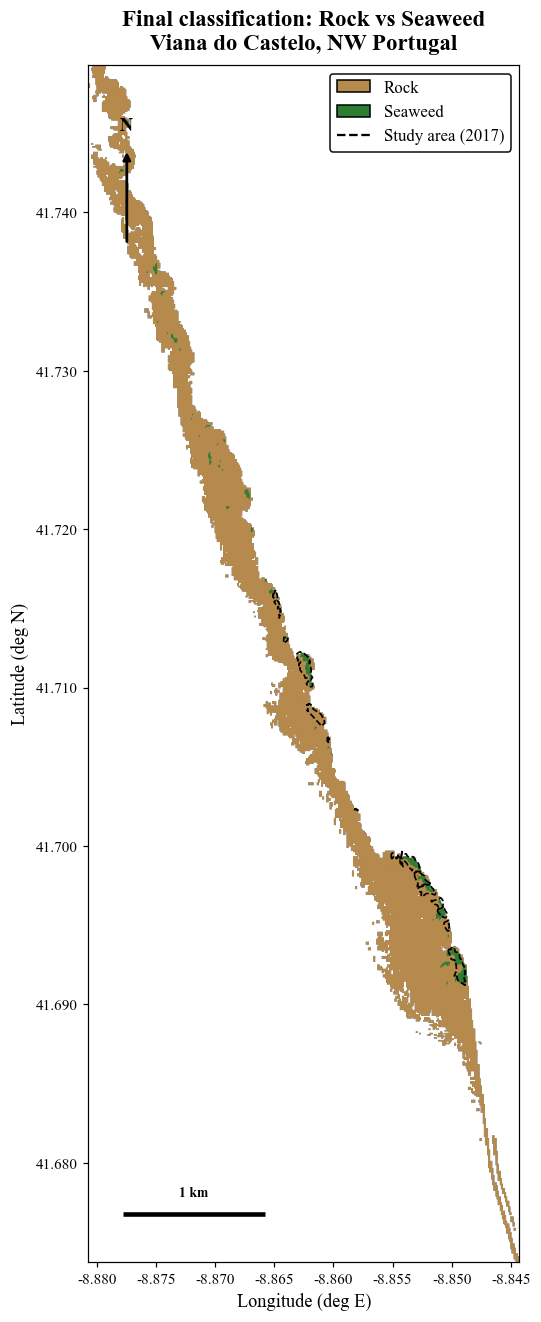

saved Final_Classification.png


In [7]:
# =============================================================================
# 4b · Individual maps  (PNG + georeferenced GeoTIFF)
# =============================================================================
map_single(prob_maps[0], cmap_rock, 0, 1, 'Probability',
           f'{CLASS_NAMES[0]} probability\nViana do Castelo, NW Portugal',
           'Class_0_Probability.png')
save_geotiff(prob_maps[0], os.path.join(GEO_DIR, 'Class_0_Probability.tif'))

map_single(prob_maps[1], cmap_seaweed, 0, 1, 'Probability',
           f'{CLASS_NAMES[1]} probability\nViana do Castelo, NW Portugal',
           'Class_1_Probability.png')
save_geotiff(prob_maps[1], os.path.join(GEO_DIR, 'Class_1_Probability.tif'))

map_single(conf_map, 'viridis', 0.5, 1.0, 'Confidence (max class probability)',
           'Classification confidence\nViana do Castelo, NW Portugal',
           'Classification_Confidence.png', overlay_poly=True)
save_geotiff(conf_map, os.path.join(GEO_DIR, 'Classification_Confidence.tif'))

map_classification('Final_Classification.png')
save_geotiff(class_map, os.path.join(GEO_DIR, 'Final_Classification.tif'), dtype='int16')

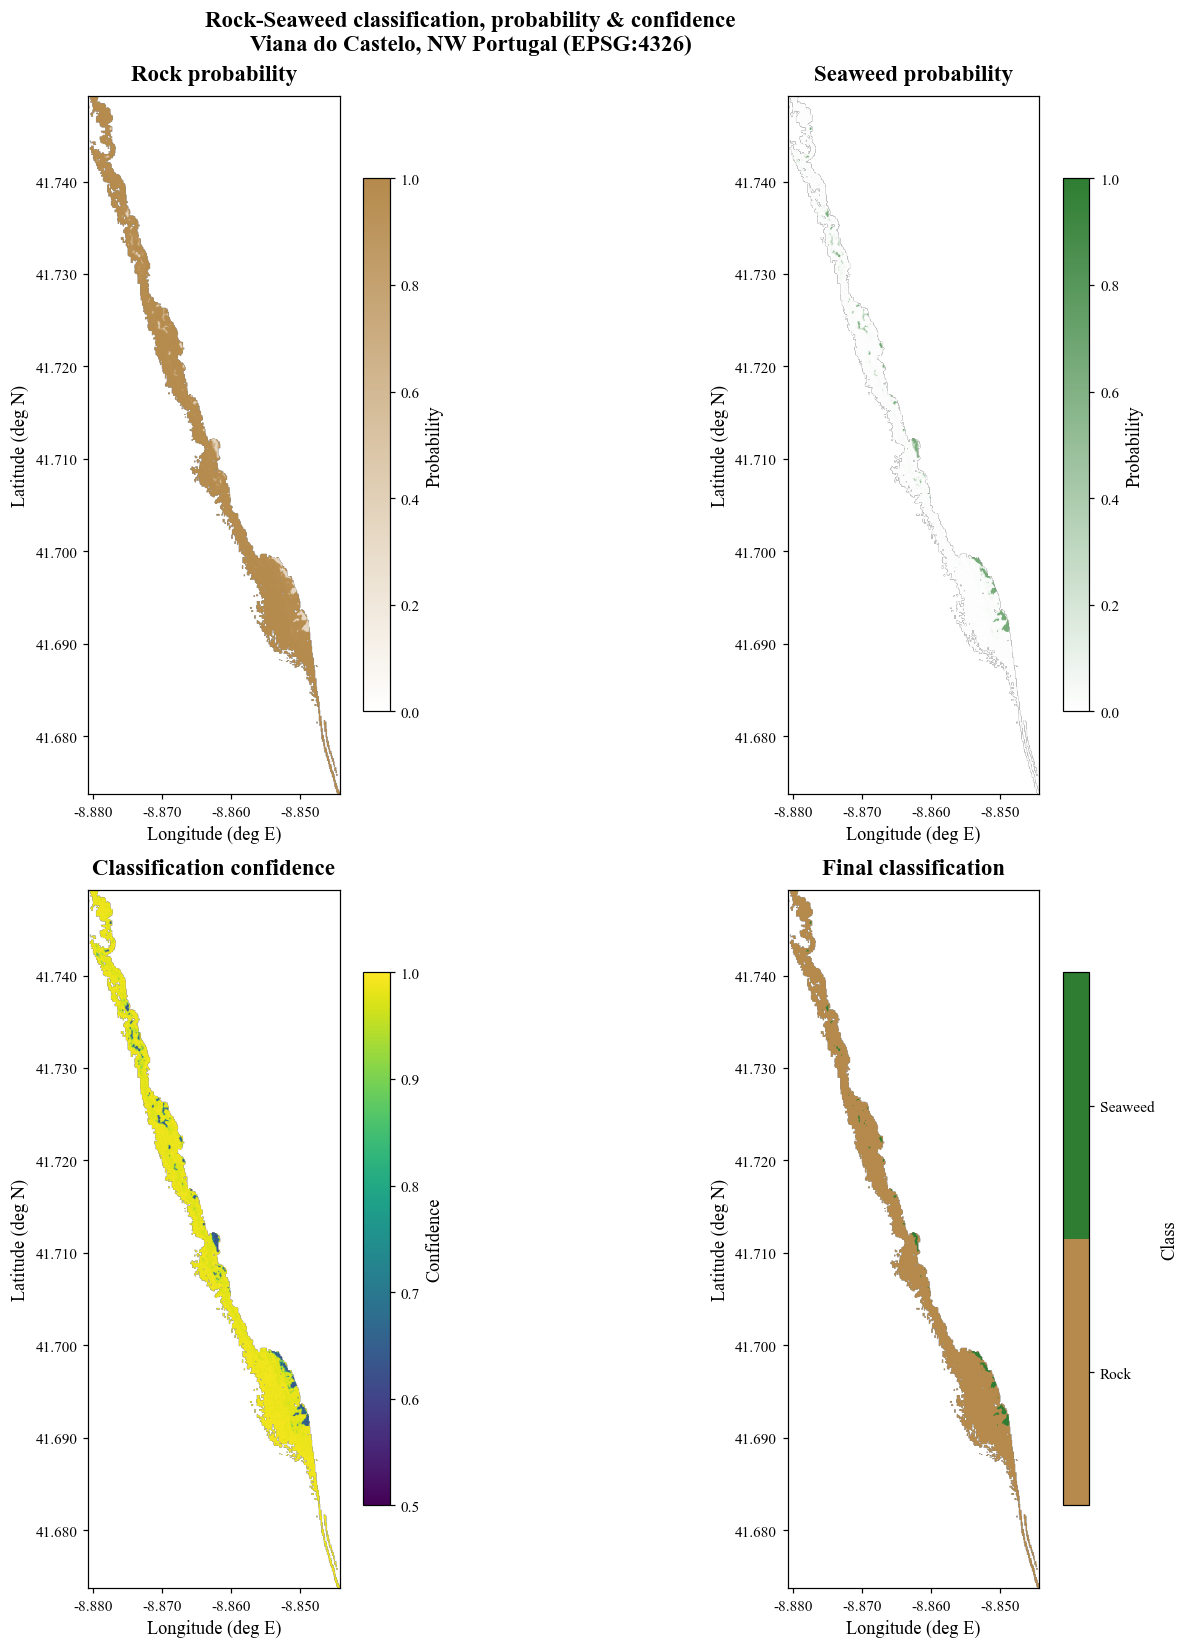

saved All_Maps_Comparison.png


In [8]:
# =============================================================================
# 4c · Combined 2x2 comparison panel
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(2 * MAP_W + 3, MAP_H + 1),
                         constrained_layout=True)
ax = axes.ravel()

panels = [
    (prob_maps[0], cmap_rock,    0, 1,   f'{CLASS_NAMES[0]} probability', 'Probability'),
    (prob_maps[1], cmap_seaweed, 0, 1,   f'{CLASS_NAMES[1]} probability', 'Probability'),
    (conf_map,     'viridis',    0.5, 1, 'Classification confidence',     'Confidence'),
]
for a, (d, cmap, vmn, vmx, ttl, clab) in zip(ax[:3], panels):
    disp = np.where(d == NODATA, np.nan, d)
    im = a.imshow(disp, cmap=cmap, vmin=vmn, vmax=vmx, extent=extent, origin='upper')
    fmt_axes(a, ttl)
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.04, label=clab)

disp = np.where(class_map == NODATA, np.nan, class_map)
im3 = ax[3].imshow(disp, cmap=cmap_class, vmin=0, vmax=1, extent=extent, origin='upper')
fmt_axes(ax[3], 'Final classification')
# discrete colorbar (same size as the other three panels -> columns stay aligned)
cbar3 = fig.colorbar(im3, ax=ax[3], fraction=0.046, pad=0.04, ticks=[0.25, 0.75])
cbar3.ax.set_yticklabels([CLASS_NAMES[0], CLASS_NAMES[1]])
cbar3.set_label('Class')

fig.suptitle('Rock-Seaweed classification, probability & confidence\n'
             'Viana do Castelo, NW Portugal (EPSG:4326)',
             fontsize=15, fontweight='bold')
fig.savefig(os.path.join(GEO_DIR, 'All_Maps_Comparison.png'))
plt.show(); plt.close(fig)
print('saved All_Maps_Comparison.png')

## 5 · Class area computation

In [9]:
# =============================================================================
# 5 · Per-class area  (reproject to UTM 29N so areas are in metres, not degrees)
# =============================================================================
from rasterio.warp import calculate_default_transform, reproject, Resampling

class_tif = os.path.join(GEO_DIR, 'Final_Classification.tif')
utm_tif   = os.path.join(GEO_DIR, 'Final_Classification_UTM29N.tif')
AREA_CRS  = 'EPSG:32629'                       # UTM zone 29N — NW Portugal

with rasterio.open(class_tif) as src:
    dst_transform, dw, dh = calculate_default_transform(
        src.crs, AREA_CRS, src.width, src.height, *src.bounds)
    meta = src.meta.copy()
    meta.update(crs=AREA_CRS, transform=dst_transform, width=dw, height=dh)
    with rasterio.open(utm_tif, 'w', **meta) as dst:
        reproject(source=rasterio.band(src, 1), destination=rasterio.band(dst, 1),
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=dst_transform, dst_crs=AREA_CRS,
                  resampling=Resampling.nearest)

with rasterio.open(utm_tif) as src:
    arr = src.read(1)
    px_w, px_h = abs(src.transform.a), abs(src.transform.e)
    px_area = px_w * px_h                       # m^2 per pixel
    nod = src.nodata
arr = arr[arr != nod] if nod is not None else arr.ravel()
vals, counts = np.unique(arr, return_counts=True)

area_m2 = counts * px_area
area_df = pd.DataFrame({
    'Class':   vals.astype(int),
    'Name':    [CLASS_NAMES.get(int(v), str(v)) for v in vals],
    'Pixels':  counts,
    'Area_m2': area_m2,
    'Area_ha': area_m2 / 10_000,
    'Percent': area_m2 / area_m2.sum() * 100,
}).round({'Area_m2': 1, 'Area_ha': 4, 'Percent': 2})

area_csv = os.path.join(FIG_DIR, 'class_area_summary.csv')
area_df.to_csv(area_csv, index=False)

print(f'Pixel size (UTM 29N): {px_w:.3f} m x {px_h:.3f} m  ->  {px_area:.4f} m2/px\n')
print(area_df.to_string(index=False))
print('\nSaved:', area_csv)

Pixel size (UTM 29N): 9.551 m x 9.551 m  ->  91.2242 m2/px

 Class    Name  Pixels   Area_m2  Area_ha  Percent
     0    Rock   19229 1754149.8 175.4150    97.28
     1 Seaweed     538   49078.6   4.9079     2.72

Saved: /Users/priyankashukla/Documents/repos/BioEcoOcean/viana_de_castelo_seaweed_classification/figures/class_area_summary.csv


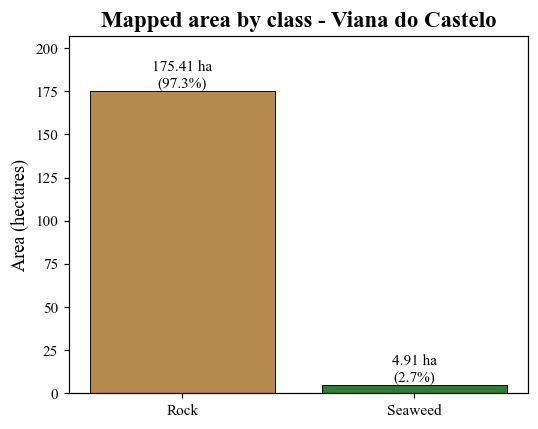

In [10]:
# ---- Figure: mapped area by class -------------------------------------------
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(area_df['Name'], area_df['Area_ha'],
              color=[CLASS_COLORS.get(int(c), '#888888') for c in area_df['Class']],
              edgecolor='black', linewidth=0.6)
for x, (ha, pct) in enumerate(zip(area_df['Area_ha'], area_df['Percent'])):
    ax.text(x, ha, f'{ha:.2f} ha\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Area (hectares)')
ax.set_title('Mapped area by class - Viana do Castelo', fontweight='bold')
ax.margins(y=0.18)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'Class_Area.png'))
plt.show()

In [11]:
# =============================================================================
# 6 · Metadata sidecar + run summary
# =============================================================================
def _mean(m):
    return float(np.nanmean(np.where(m == NODATA, np.nan, m)))

meta = [
    'GEOREFERENCED MAPS - METADATA',
    f'Generated: {datetime.now():%Y-%m-%d %H:%M:%S}',
    '',
    'STUDY AREA : Viana do Castelo, NW Portugal',
    f'CRS        : {crs}',
    f'Extent lon : {bounds.left:.6f} to {bounds.right:.6f}',
    f'Extent lat : {bounds.bottom:.6f} to {bounds.top:.6f}',
    f'Raster     : {W} x {H} px, {bands} bands',
    '',
    'MODEL      : Random Forest (100 trees, max_depth=15, class_weight=balanced)',
    f'Overall accuracy : {oa:.3f}',
    f'Cohen kappa      : {kappa:.3f}',
    '',
    'MEAN VALUES:',
    f'  Rock probability    : {_mean(prob_maps[0]):.3f}',
    f'  Seaweed probability : {_mean(prob_maps[1]):.3f}',
    f'  Confidence          : {_mean(conf_map):.3f}',
    '',
    'MAPPED AREA (UTM 29N, EPSG:32629):',
]
meta += [f'  {n:8s}: {ha:.3f} ha ({p:.1f}%)'
         for n, ha, p in zip(area_df.Name, area_df.Area_ha, area_df.Percent)]
meta += [
    '',
    'FILES (figures/georeferenced_maps/):',
    '  Final_Classification.png / .tif',
    '  Final_Classification_UTM29N.tif',
    '  Class_0_Probability.png / .tif   (Rock)',
    '  Class_1_Probability.png / .tif   (Seaweed)',
    '  Classification_Confidence.png / .tif',
    '  All_Maps_Comparison.png',
    '',
    'FILES (figures/):',
    '  Model_Evaluation.png',
    '  Class_Area.png',
    '  class_area_summary.csv',
]
with open(os.path.join(GEO_DIR, 'METADATA.txt'), 'w') as f:
    f.write('\n'.join(meta))

print('\n'.join(meta))
print('\nAll outputs written under', FIG_DIR)

GEOREFERENCED MAPS - METADATA
Generated: 2026-09-17 21:14:42

STUDY AREA : Viana do Castelo, NW Portugal
CRS        : EPSG:4326
Extent lon : -8.880745 to -8.844273
Extent lat : 41.673744 to 41.749293
Raster     : 406 x 841 px, 13 bands

MODEL      : Random Forest (100 trees, max_depth=15, class_weight=balanced)
Overall accuracy : 0.948
Cohen kappa      : 0.889

MEAN VALUES:
  Rock probability    : 0.960
  Seaweed probability : 0.040
  Confidence          : 0.968

MAPPED AREA (UTM 29N, EPSG:32629):
  Rock    : 175.415 ha (97.3%)
  Seaweed : 4.908 ha (2.7%)

FILES (figures/georeferenced_maps/):
  Final_Classification.png / .tif
  Final_Classification_UTM29N.tif
  Class_0_Probability.png / .tif   (Rock)
  Class_1_Probability.png / .tif   (Seaweed)
  Classification_Confidence.png / .tif
  All_Maps_Comparison.png

FILES (figures/):
  Model_Evaluation.png
  Class_Area.png
  class_area_summary.csv

All outputs written under /Users/priyankashukla/Documents/repos/BioEcoOcean/viana_de_castelo_se